# Introduction

The objective of this notebook is to perform a data analysis on the Workforce Management (WFM) Metrics dataset, sourced from [Kaggle](https://www.kaggle.com/datasets/antaesterlin/call-center-metrics). This analysis aims to provide actionable insights into key call center performance indicators, with a particular focus on Service Level Agreements (SLAs), customer satisfaction (CSAT), operational efficiency, and agent scheduling.

Throughout this notebook, I will address the following key questions:

- Where do our SLAs and metrics currently stand, and how can we effectively communicate this status to stakeholders?
- How can we create regular health reports to monitor the status of our queues and articulate findings to stakeholders?
- What decisions and actions can be taken proactively based on data analysis and best practices?
- How can we improve SLAs, operational efficiency, and agent distribution through precise communication and collaboration?

![WFM Analysis](https://images.unsplash.com/photo-1519389950473-47ba0277781c?auto=format&fit=crop&w=800&q=80)

# 1.0 Executive Summary

SLA performance during October remained consistently below the expected 80% target, with only ~62% of interactions meeting service level expectations.

This underperformance is not driven by isolated incidents, but by a structural imbalance in how workload is distributed across call centers.

Call volume is persistently concentrated in specific locations, creating sustained overload in high-demand centers while others remain underutilized.

Additionally, customer sentiment indicates recurring friction points, particularly related to service outages, reinforcing the operational impact of these inefficiencies.

Addressing workload distribution and improving incident visibility represent the most critical levers to improve SLA performance and overall customer experience.

# 2.0 Data Processing

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

In [74]:
df = pd.read_csv("call-center.csv") 

In [75]:
df = df.drop(columns=["Avg Satisfaction Score", "Avg Call Duration(min)"])

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [76]:
df["id"] = df["id"].astype("string")
df["customer_name"] = df["customer_name"].astype("string")

df = df.rename(columns={"response_time": "SLA"})


categorical_cols = [
    "sentiment", "reason", "city", "state",
    "channel", "call_center", "SLA"
]

for col in categorical_cols:
    df[col] = df[col].astype("category")


df["csat_score"] = pd.to_numeric(df["csat_score"], errors="coerce")  # mantém float64
df["call_day"] = pd.to_numeric(df["call_day"], errors="coerce").astype("int64")

df["call_duration_in_minutes"] = pd.to_numeric(
    df["call_duration_in_minutes"], errors="coerce"
).astype("int64")


df["call_timestamp"] = pd.to_datetime(df["call_timestamp"], errors="coerce")


df = df.rename(columns={"call_duration_in_minutes": "aht"})

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32941 entries, 0 to 32940
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              32940 non-null  string        
 1   customer_name   32941 non-null  string        
 2   sentiment       32941 non-null  category      
 3   csat_score      12271 non-null  float64       
 4   call_timestamp  32941 non-null  datetime64[ns]
 5   call_day        32941 non-null  int64         
 6   reason          32941 non-null  category      
 7   city            32941 non-null  category      
 8   state           32941 non-null  category      
 9   channel         32941 non-null  category      
 10  SLA             32941 non-null  category      
 11  aht             32941 non-null  int64         
 12  call_center     32941 non-null  category      
dtypes: category(7), datetime64[ns](1), float64(1), int64(2), string(2)
memory usage: 1.8 MB


In [78]:
sla_map = {
    "Above SLA": 1,
    "Within SLA": 0,
    "Below SLA": -1
}

df["sla_score"] = df["SLA"].map(sla_map)

# 2.0 - Data Analysis

## 2.1 Current Performance (SLA)

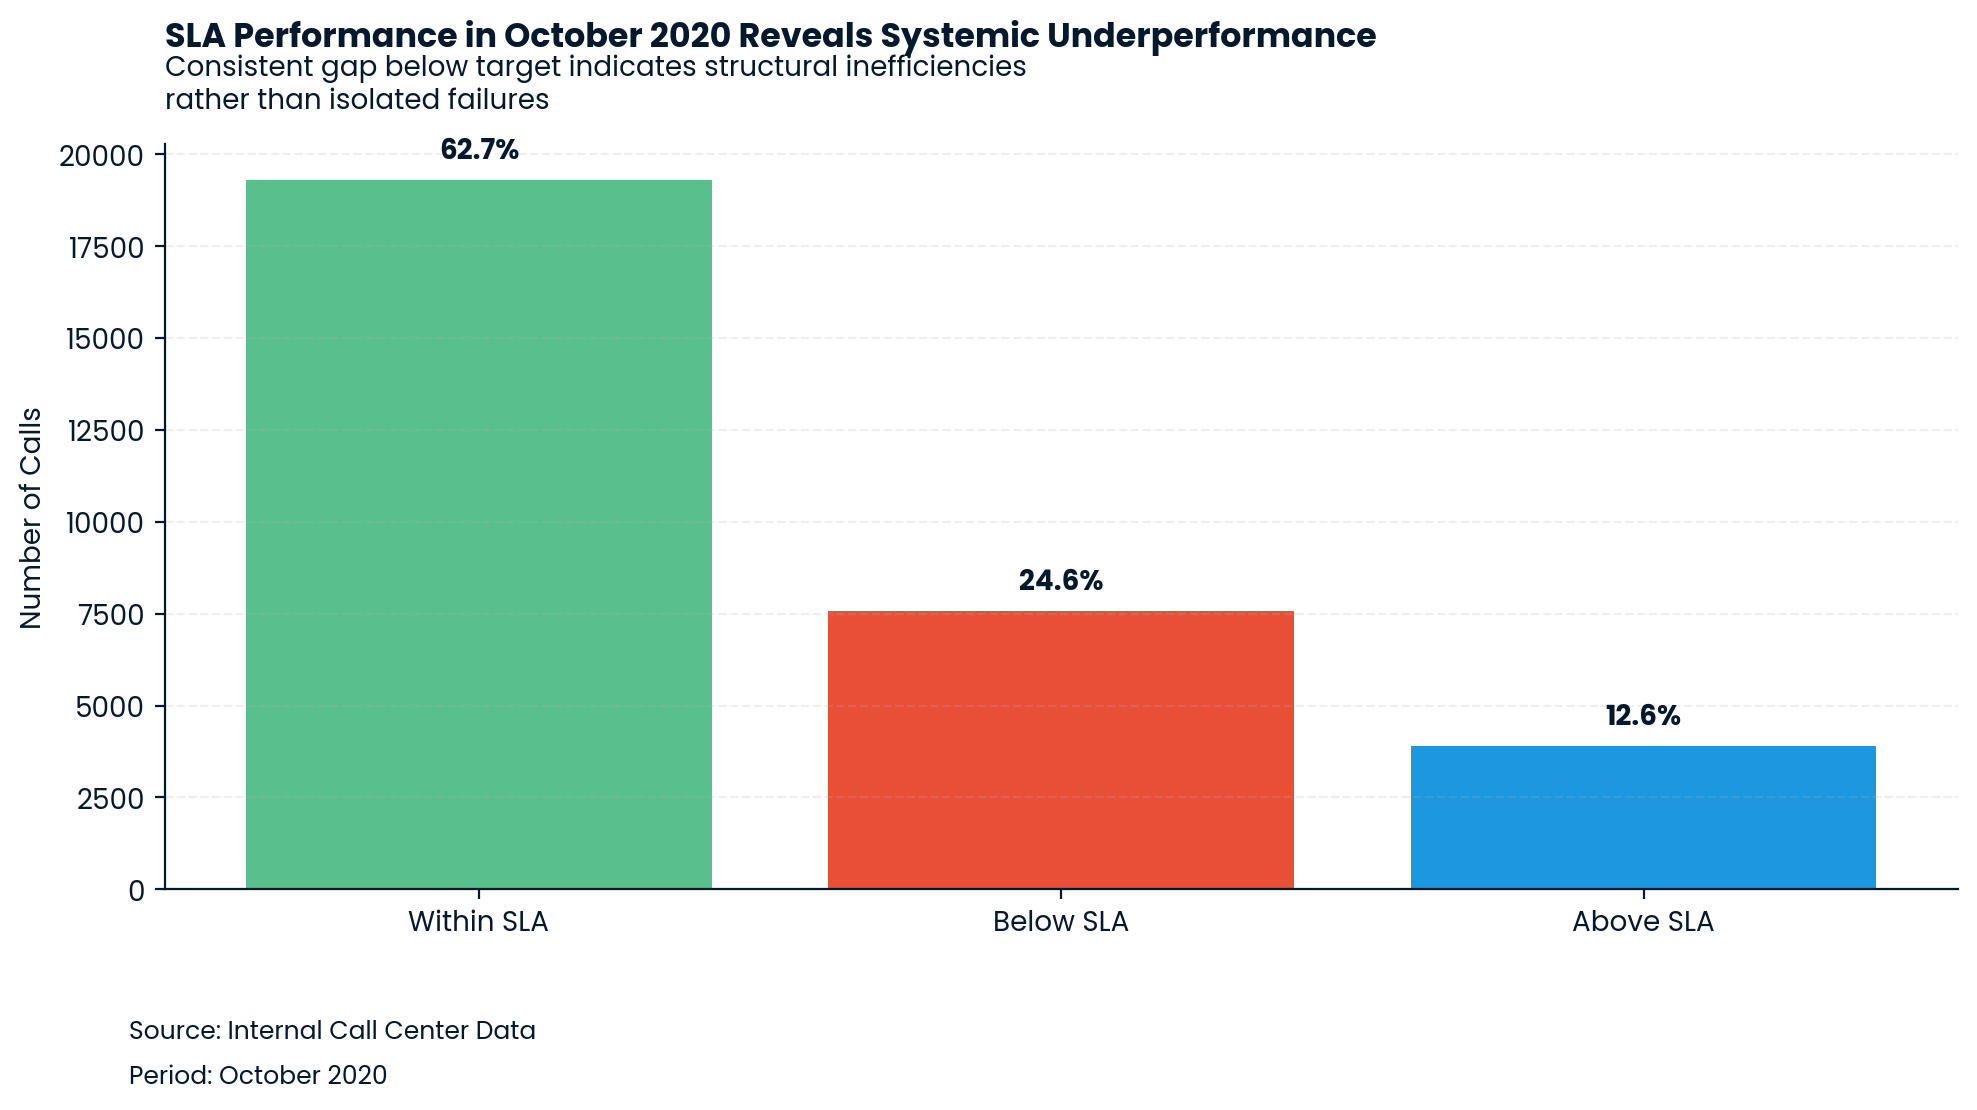

In [89]:
sla_counts = df["SLA"].value_counts()

# garantir ordem lógica
order = ["Below SLA", "Within SLA", "Above SLA"]
sla_counts = sla_counts.reindex(order)

# remover categorias ausentes (caso alguma não exista)
sla_counts = sla_counts.dropna()

# ordenar do maior para o menor
sla_counts = sla_counts.sort_values(ascending=False)

# calcular percentual
sla_pct = sla_counts / sla_counts.sum() * 100

# =========================
# 2. Plot
# =========================

plt.figure(figsize=(10, 6))
ax = plt.gca()

colors = {
    "Below SLA": "#E94F37",   # vermelho (problema)
    "Within SLA": "#59BF8D",  # verde (ok)
    "Above SLA": "#1B98E0"    # azul (ótimo)
}

bars = ax.bar(
    sla_counts.index,
    sla_counts.values,
    color=[colors[k] for k in sla_counts.index]
)

# =========================
# 3. Labels diretos (apenas %)
# =========================

for i, pct in enumerate(sla_pct.values):
    ax.text(
        i,
        sla_counts.values[i] + (sla_counts.max() * 0.02),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# =========================
# 4. Estilo visual
# =========================

# remover bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# grid leve
plt.grid(axis='y', linestyle='--', alpha=0.2)

# remover labels redundantes
plt.xlabel("")
plt.ylabel("Number of Calls")

# =========================
# 5. Título + subtítulo
# =========================

title = "SLA Performance in October Reveals Systemic Underperformance"

subtitle = (
    "Consistent gap below target indicates structural inefficiencies\nrather than isolated failures"
)

ax.text(
    0.0, 1.12,
    title,
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=12,
    fontweight='bold'
)

ax.text(
    0.0, 1.04,
    subtitle,
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=10
)

# =========================
# 6. Fonte + período
# =========================

ax.text(
    -0.02, -0.20,
    "Source: Internal Call Center Data",
    transform=ax.transAxes,
    ha='left',
    fontsize=9
)

ax.text(
    -0.02, -0.26,
    "Period: October 2020",
    transform=ax.transAxes,
    ha='left',
    fontsize=9
)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

SLA compliance during October remained consistently below the 80% target, with approximately 62% of interactions meeting SLA and nearly 25% falling below expectations.

The distribution is stable across the period, indicating that underperformance is not driven by isolated spikes, but by a persistent operational pattern.

This suggests that current capacity and workload management strategies are not sufficient to absorb demand efficiently, resulting in a sustained service level gap.

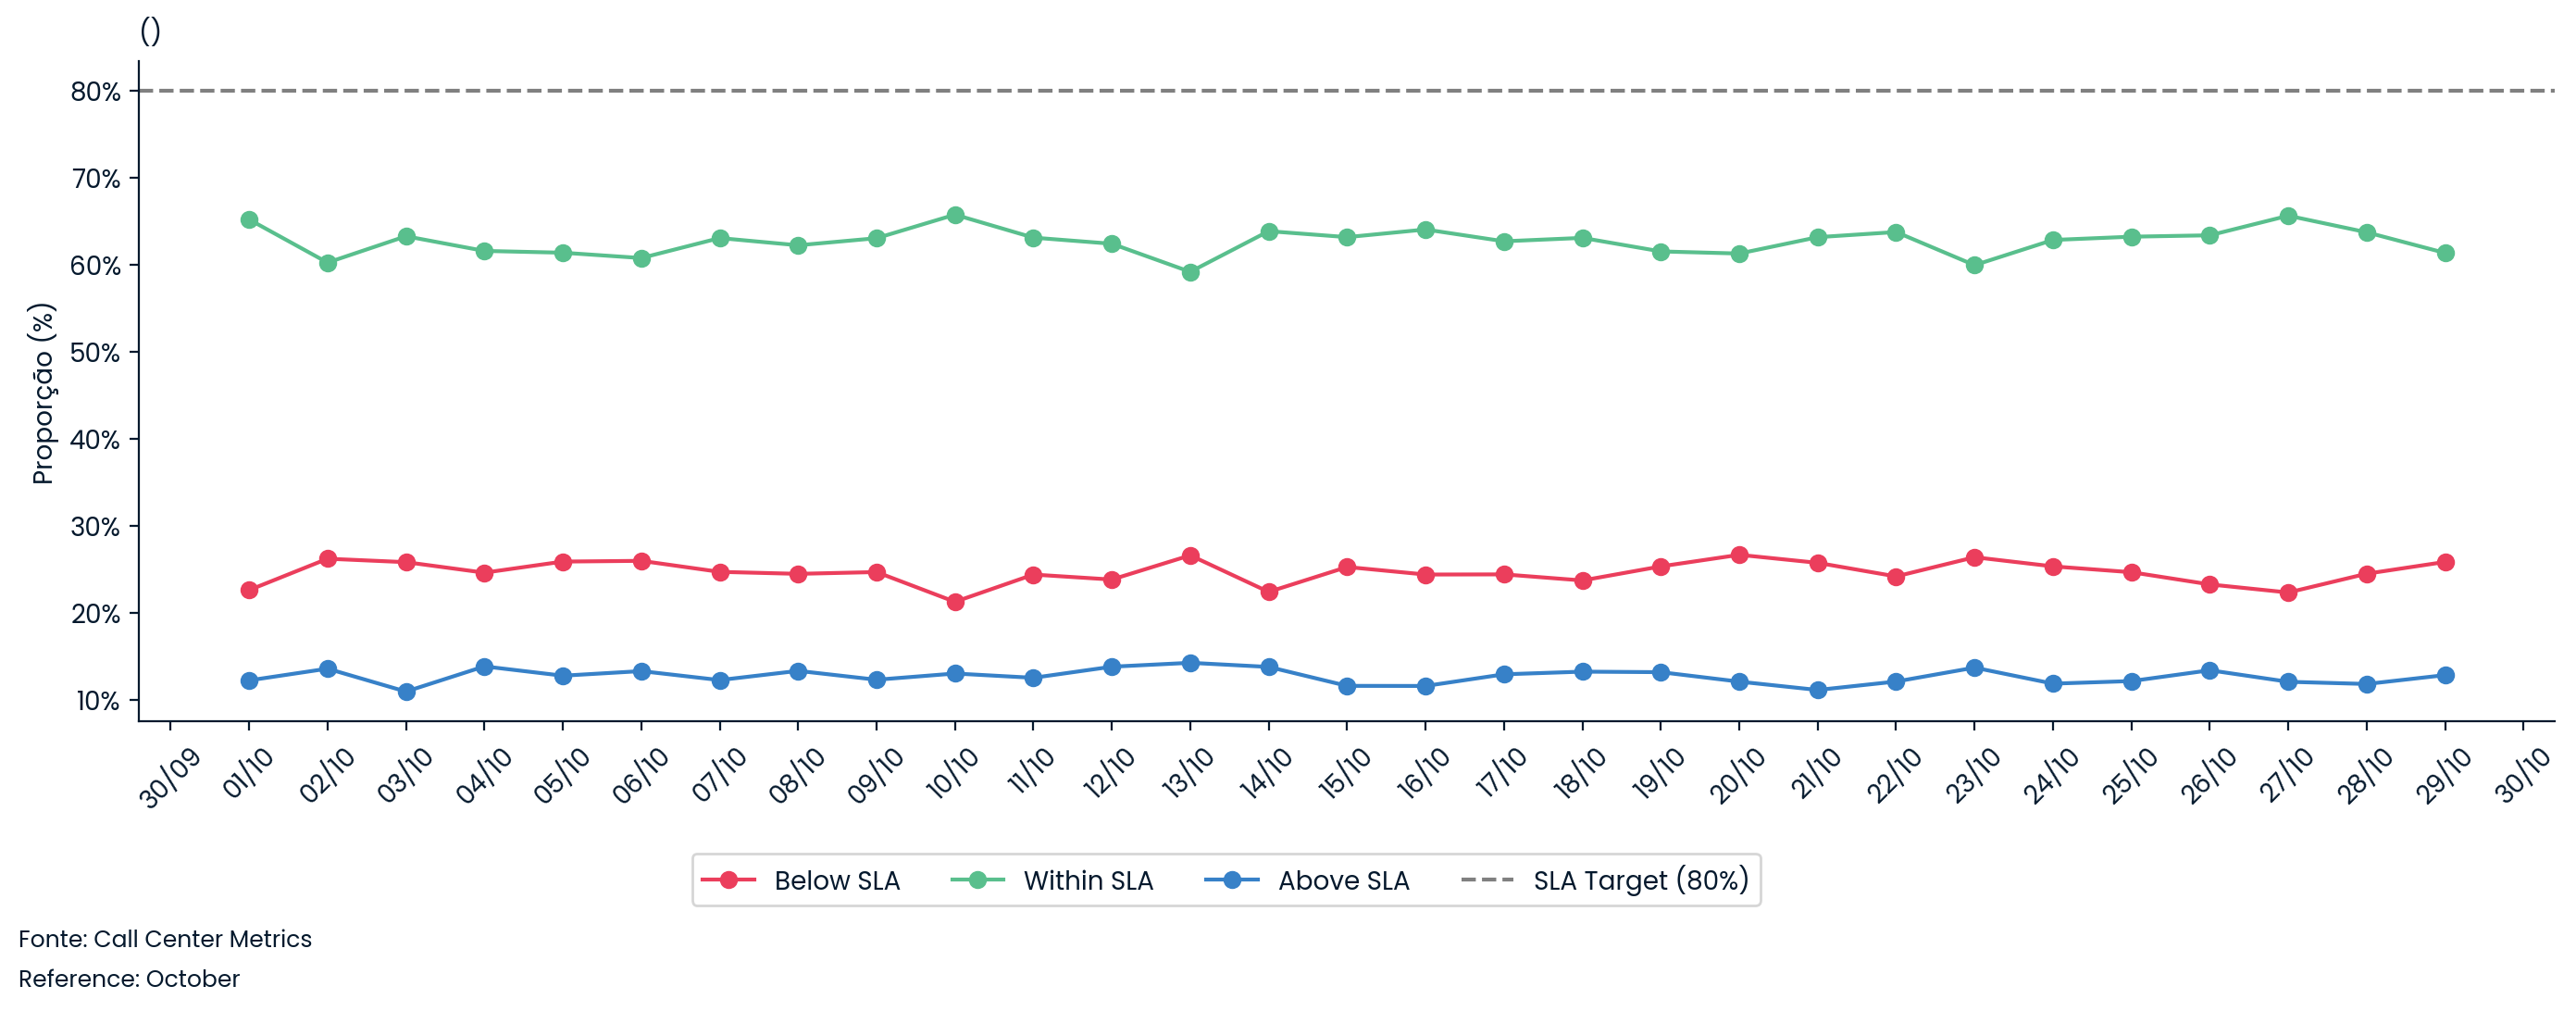

In [80]:
# =========================
# 1. Preparação
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

# garantir datetime
df["call_timestamp"] = pd.to_datetime(df["call_timestamp"])
df["date"] = df["call_timestamp"].dt.floor("D")

# fixar período de outubro
start_date = "2020-10-01"
end_date = "2020-10-29"

df = df[
    (df["date"] >= start_date) &
    (df["date"] <= end_date)
]

# =========================
# 2. Pivot ROBUSTO (corrigido)
# =========================

pivot = (
    df.groupby(["date", "SLA"])
      .size()
      .unstack()
)

# garantir TODAS as colunas (categorias SLA)
pivot = pivot.reindex(
    columns=["Below SLA", "Within SLA", "Above SLA"],
    fill_value=0
)

# garantir TODAS as datas do mês
full_range = pd.date_range(start=start_date, end=end_date, freq="D")
pivot = pivot.reindex(full_range, fill_value=0)

pivot.index.name = "date"

# =========================
# 3. Normalização segura
# =========================

total = pivot.sum(axis=1)

# evita divisão por zero (dias sem dados)
pivot = pivot.div(total.replace(0, 1), axis=0)

# =========================
# 4. Plot
# =========================

colors = {
    "Below SLA": "#EB3E5C",
    "Within SLA": "#59BF8D",
    "Above SLA": "#3781C8"
}

plt.figure(figsize=(14, 6))

for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], label=col, color=colors[col], marker='o')

# linha de meta
plt.axhline(y=0.8, linestyle="--", color="gray", label="SLA Target (80%)")

# formato %
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax = plt.gca()

# remover bordas desnecessárias
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# =========================
# 5. Eixo X (todas as datas)
# =========================

ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

plt.xticks(rotation=45)

# =========================
# 6. Textos
# =========================

ax.text(x=-0.05, y=-0.34, s='Fonte: Call Center Metrics', fontsize=9,
        transform=ax.transAxes, ha='left')

ax.text(x=-0.05, y=-0.40, s='Reference: October', fontsize=9,
        transform=ax.transAxes, ha='left')

# título
title = ''

subtitle = (
)

ax.text(
    0.0, 1.11,
    title,
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=12,
    fontweight='bold'
)

ax.text(
    0.0, 1.02,
    subtitle,
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=10
)

# label eixo Y
plt.ylabel("Proporção (%)")

# legenda
plt.legend(loc='upper center', bbox_to_anchor=(0.45, -0.18), ncol=4)

plt.tight_layout()
plt.show()

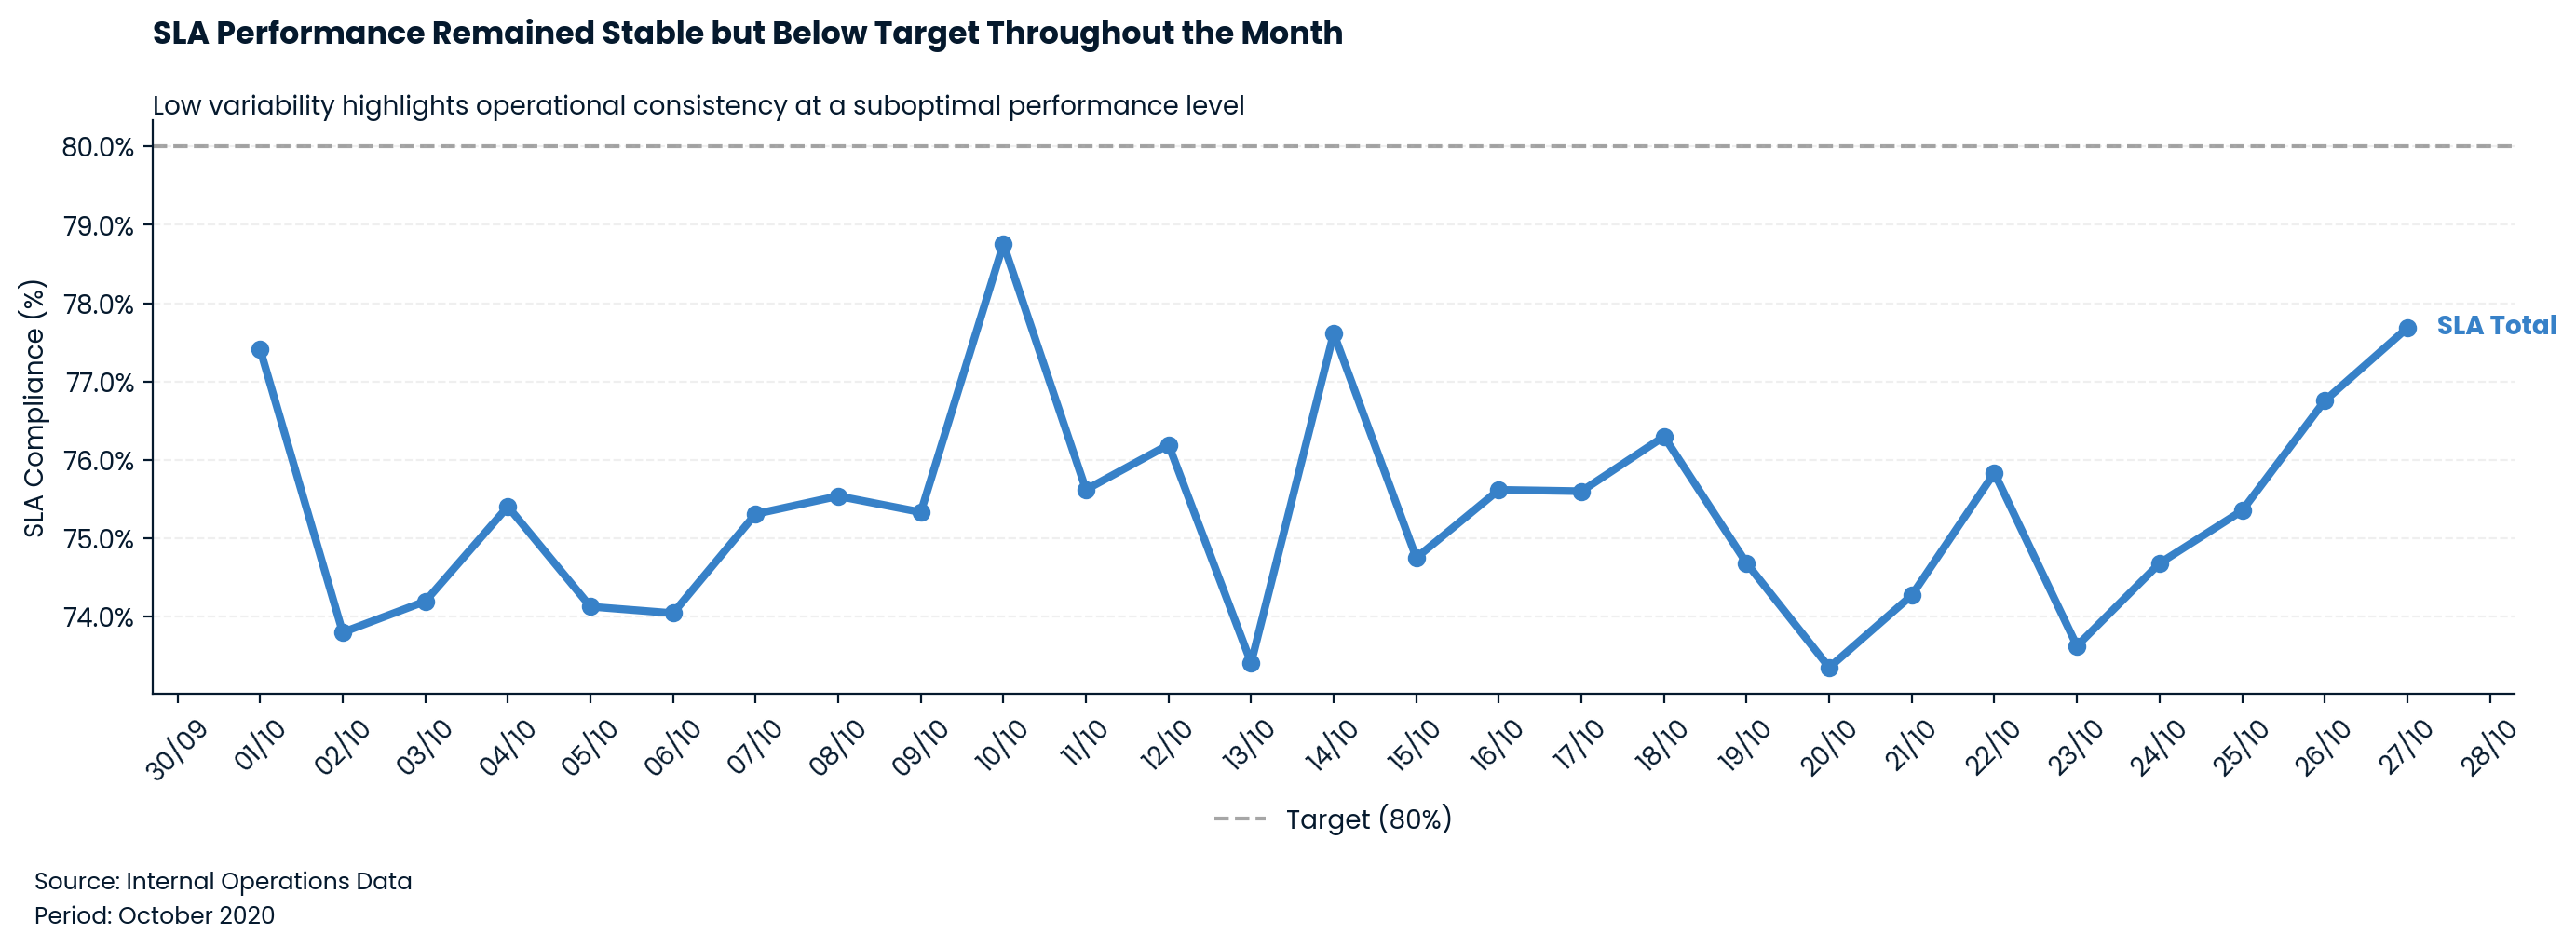

In [90]:
# =========================
# 1. Preparação
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

df["call_timestamp"] = pd.to_datetime(df["call_timestamp"])
df["date"] = df["call_timestamp"].dt.floor("D")

# remover último dia (incompleto)
df = df[df["date"] < df["date"].max()]

# =========================
# 2. Distribuição SLA
# =========================

pivot = (
    df.groupby(["date", "SLA"])
      .size()
      .unstack(fill_value=0)
)

pivot = pivot[["Below SLA", "Within SLA", "Above SLA"]]
pivot = pivot.div(pivot.sum(axis=1), axis=0)

# garantir continuidade temporal
full_range = pd.date_range(
    start=pivot.index.min(),
    end=pivot.index.max(),
    freq="D"
)

pivot = pivot.reindex(full_range)
pivot.index.name = "date"

# =========================
# 3. SLA TOTAL
# =========================

pivot["SLA_total"] = pivot["Within SLA"] + pivot["Above SLA"]

# =========================
# 4. Plot
# =========================

plt.figure(figsize=(14, 6))
ax = plt.gca()

# linha principal
line, = ax.plot(
    pivot.index,
    pivot["SLA_total"],
    color="#3781C8",
    marker='o',
    linewidth=3,
    zorder=3,
    label="SLA Total"
)

# linha de target (agora com legenda)
target = 0.8
ax.axhline(
    y=target,
    linestyle="--",
    color="gray",
    linewidth=1.5,
    alpha=0.7,
    label="Target (80%)"
)

# =========================
# 5. Label direto (só série principal)
# =========================

x_margin = pd.Timedelta(days=0.3)

ax.text(
    pivot.index[-1] + x_margin,
    pivot["SLA_total"].iloc[-1],
    " SLA Total",
    color=line.get_color(),
    va='center',
    fontsize=10,
    fontweight='bold'
)

# =========================
# 6. Formatação
# =========================

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

plt.xticks(rotation=45)

# remover bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# grid leve
plt.grid(axis='y', linestyle='--', alpha=0.2)

# =========================
# 7. Narrativa
# =========================

title = "SLA Performance Remained Stable but Below Target Throughout the Month"

subtitle = (
    "Low variability highlights operational consistency at a suboptimal performance level"
)

ax.text(
    0.0, 1.12,
    title,
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=12,
    fontweight='bold'
)

ax.text(
    0.0, 1.0,
    subtitle,
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=10
)

# =========================
# 8. Metadados
# =========================

ax.text(
    x=-0.05, y=-0.34,
    s='Source: Internal Operations Data',
    fontsize=9,
    transform=ax.transAxes,
    ha='left'
)

ax.text(
    x=-0.05, y=-0.40,
    s=f'Period: {pivot.index.min().strftime("%B %Y")}',
    fontsize=9,
    transform=ax.transAxes,
    ha='left'
)

# =========================
# 9. Legenda centralizada (apenas target)
# =========================

plt.legend(
    handles=[ax.lines[1]],  # apenas a linha do target
    labels=["Target (80%)"],
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=1,
    frameon=False
)

# =========================
# 10. Finalização
# =========================

plt.xlabel("")
plt.ylabel("SLA Compliance (%)")

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

Daily SLA performance shows limited variability, remaining within a narrow range throughout October.

Despite this stability, performance does not reach the defined target at any sustained point, reinforcing that the issue is systemic.

This pattern indicates that the operation is consistently executing below expected capacity efficiency, rather than reacting to temporary disruptions.

## 2.2 Workload Distribution

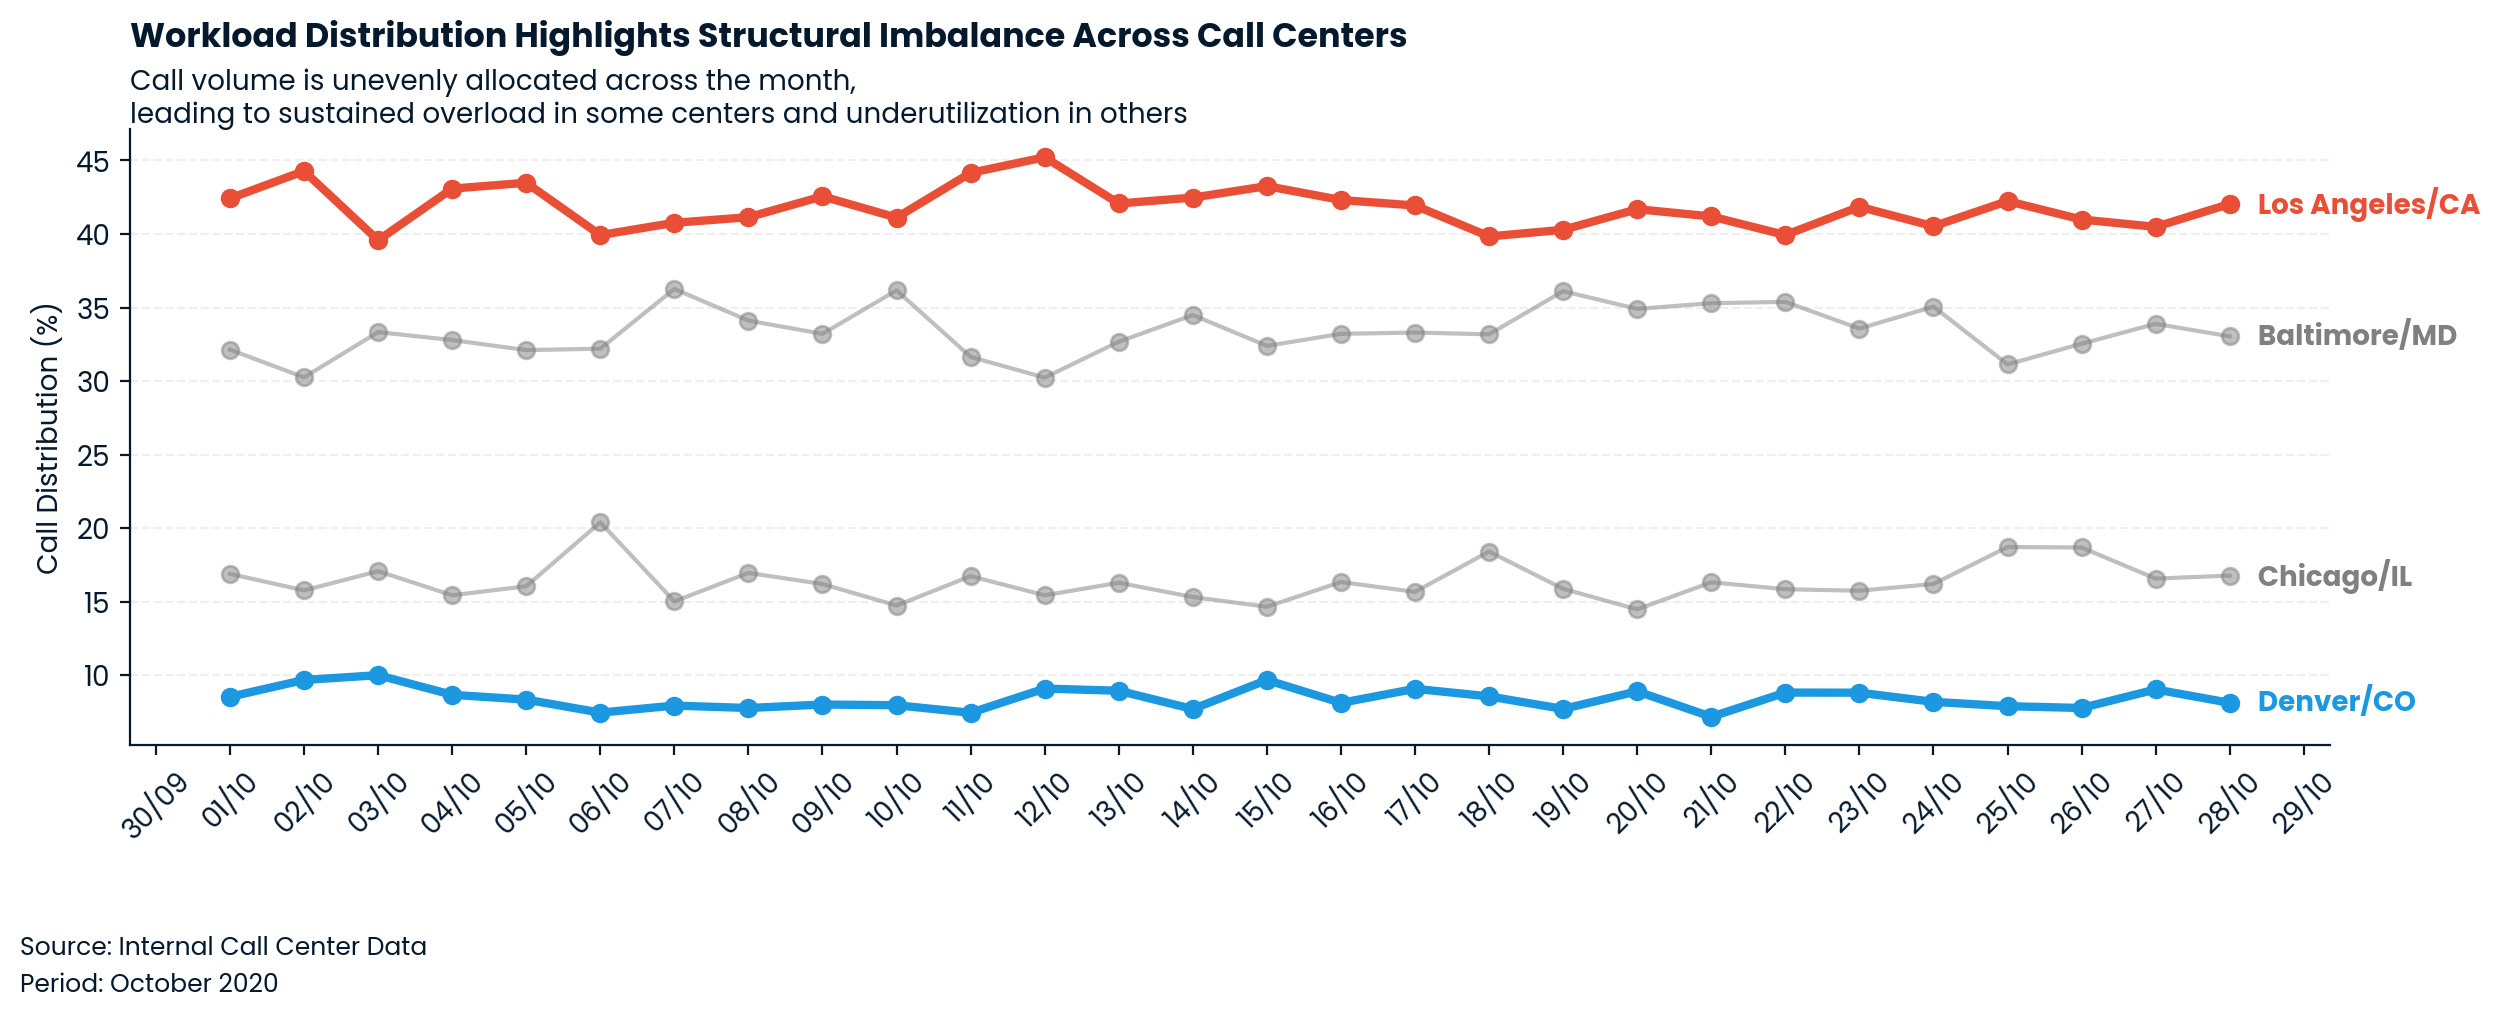

In [82]:
# =========================
# 1. Preparation
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ensure datetime
df["call_timestamp"] = pd.to_datetime(df["call_timestamp"])
df["date"] = df["call_timestamp"].dt.floor("D")

# fix October period
start_date = "2020-10-01"
end_date = "2020-10-28"

df_calls = df[
    (df["date"] >= start_date) &
    (df["date"] <= end_date)
]

# =========================
# 2. Pivot: Percentage of calls per call_center and date
# =========================

calls_pivot = (
    df_calls.groupby(["date", "call_center"])
            .size()
            .unstack(fill_value=0)
)

# ensure ALL dates in the month
full_range = pd.date_range(start=start_date, end=end_date, freq="D")
calls_pivot = calls_pivot.reindex(full_range, fill_value=0)
calls_pivot.index.name = "date"

# Convert to percentage per day
calls_pct = calls_pivot.div(calls_pivot.sum(axis=1), axis=0) * 100

# =========================
# 3. Plot
# =========================

plt.figure(figsize=(14, 6))

highlight_centers = {
    "Los Angeles/CA": "#E94F37",
    "Denver/CO": "#1B98E0"
}

ax = plt.gca()

for col in calls_pct.columns:
    if col in highlight_centers:
        line, = ax.plot(
            calls_pct.index, calls_pct[col],
            marker='o',
            label=col,
            color=highlight_centers[col],
            linewidth=3,
            zorder=3
        )
    else:
        line, = ax.plot(
            calls_pct.index, calls_pct[col],
            marker='o',
            label=col,
            color='gray',
            alpha=0.5,
            linewidth=1.5,
            zorder=2
        )
    # Add legend label directly to the last point of each line, with a small margin
    x_margin = pd.Timedelta(days=0.3)  # ~1/3 day to the right
    ax.text(
        calls_pct.index[-1] + x_margin, 
        calls_pct[col].iloc[-1], 
        f' {col}', 
        color=line.get_color(), 
        va='center', 
        fontsize=10, 
        fontweight='bold'
    )

# X axis: all dates
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
plt.xticks(rotation=45)

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(x=-0.05, y=-0.34, s='Source: Internal Call Center Data', fontsize=9,
        transform=ax.transAxes, ha='left')

ax.text(x=-0.05, y=-0.40, s='Period: October 2020', fontsize=9,
        transform=ax.transAxes, ha='left')

# título
title = 'Uneven Workload Distribution Drives Operational Imbalance Across Call Centers'

subtitle = ('Persistent concentration of demand creates overload in some centers and idle capacity in others')

ax.text(
    0.0, 1.12,
    title,
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=12,
    fontweight='bold'
)

ax.text(
    0.0, 1.0,
    subtitle,
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=10
)


plt.xlabel("")
plt.ylabel("Call Distribution (%)")
plt.grid(axis='y', linestyle='--', alpha=0.2)


plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.show()

Call volume during October was consistently unevenly distributed across call centers.

Los Angeles and Baltimore handled a disproportionately high share of interactions, while centers such as Denver remained significantly underutilized.

This imbalance persisted throughout the entire period, indicating that workload distribution was not dynamically adjusted based on demand.

As a result, overloaded centers experienced sustained pressure, increasing SLA breaches, while available capacity in other locations remained unused.

This structural inefficiency is the primary driver of the SLA underperformance observed during the month.

## 2.3 Operational Drivers & Customer Experience Insights

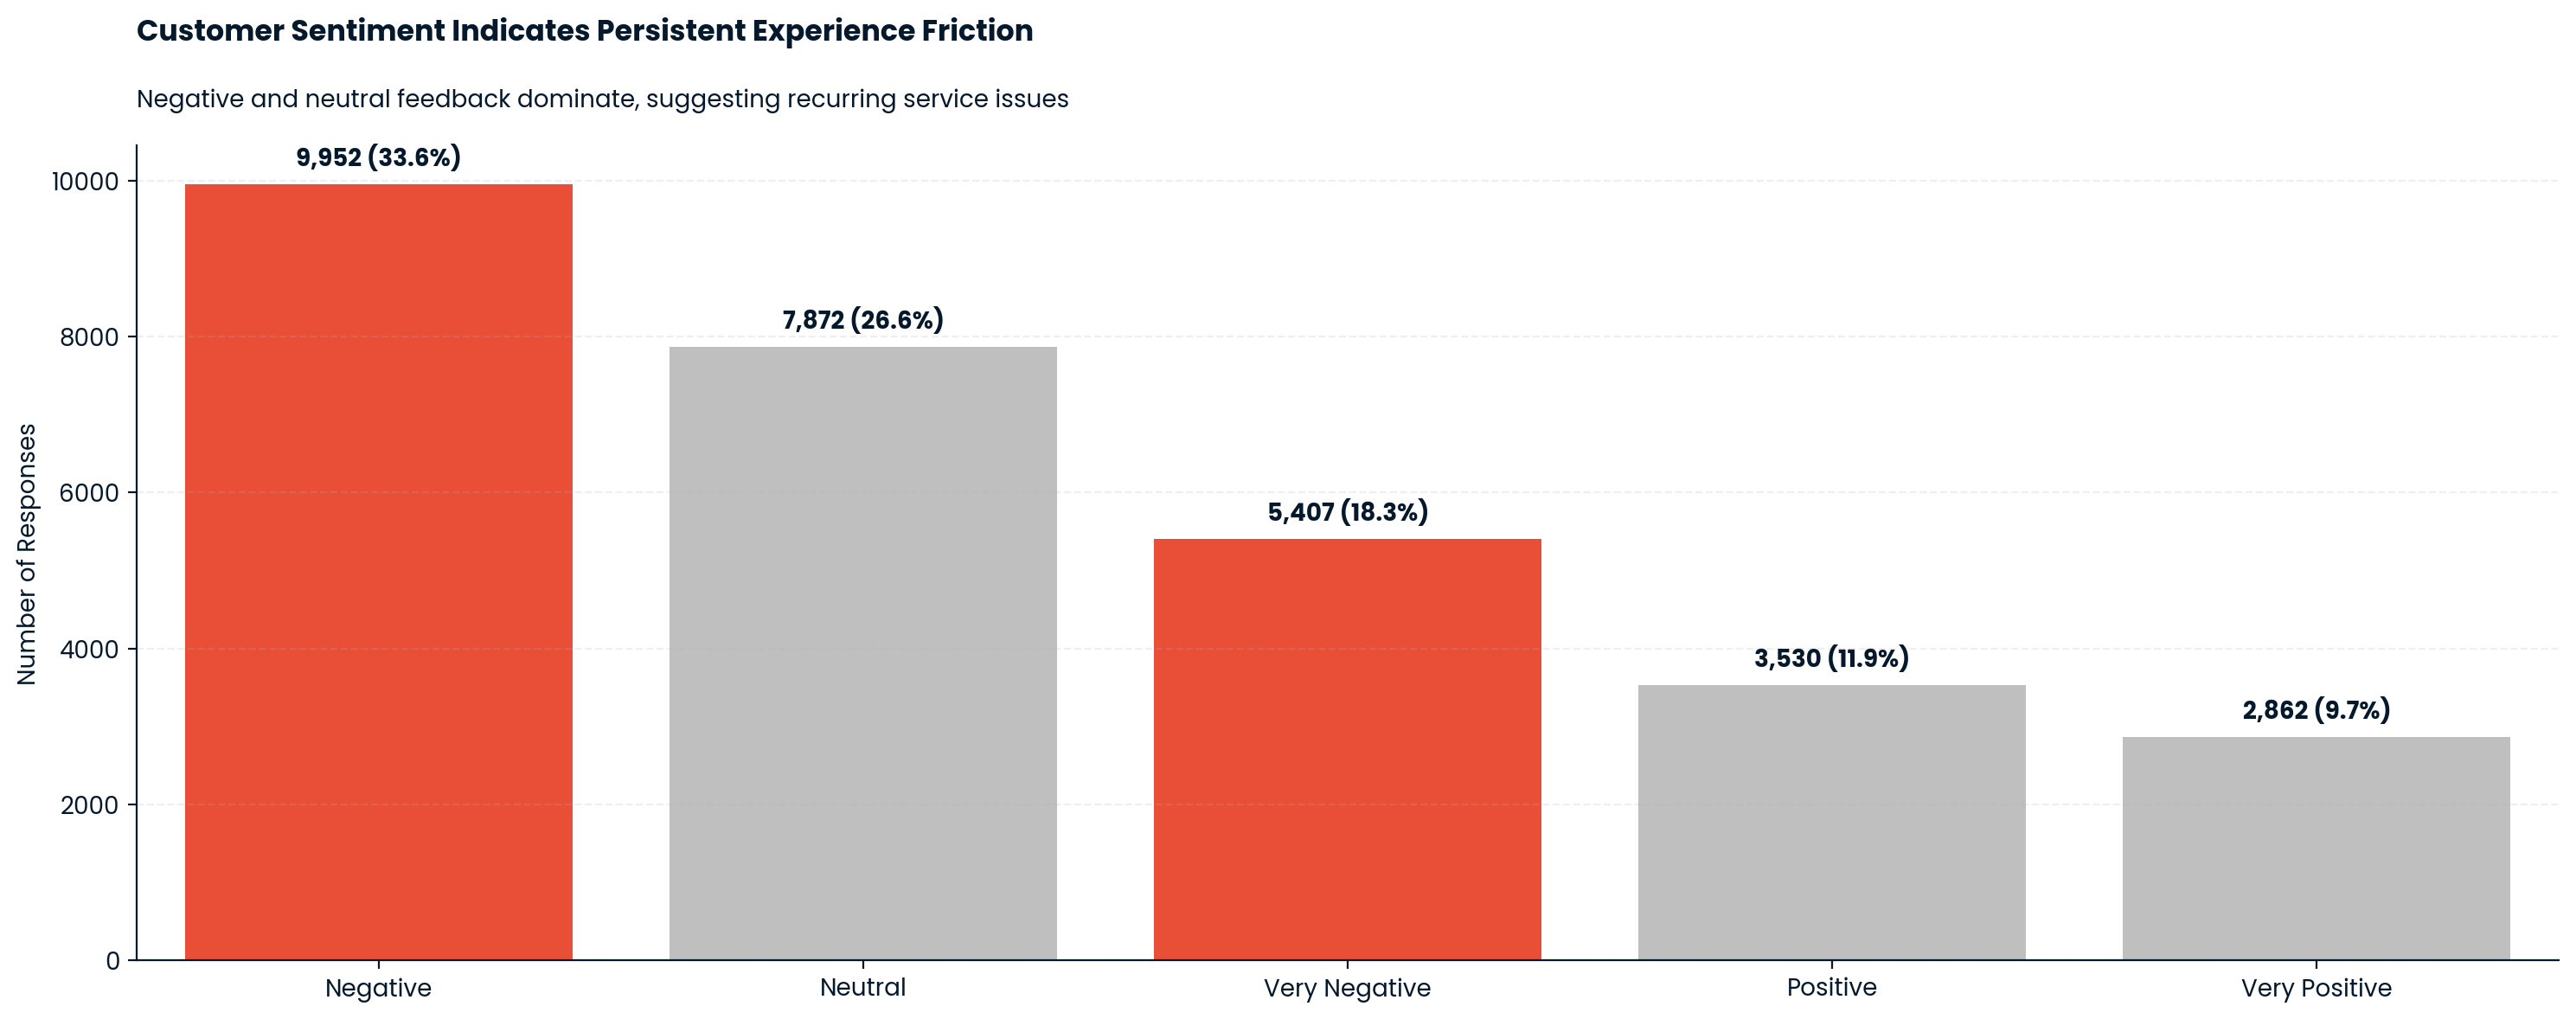

In [91]:
# =========================
# 1. Preparação
# =========================

import pandas as pd
import matplotlib.pyplot as plt

sentiment_counts = df["sentiment"].value_counts()

# ordenar decrescente
sentiment_counts = sentiment_counts.sort_values(ascending=False)

# calcular porcentagem
total = sentiment_counts.sum()
percentages = sentiment_counts / total * 100

# =========================
# 2. Plot
# =========================

plt.figure(figsize=(10, 6))
ax = plt.gca()

# highlight negativos
highlight = ["Very Negative", "Negative"]

colors = [
    "#E94F37" if cat in highlight else "gray"
    for cat in sentiment_counts.index
]

bars = ax.bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=colors
)

# suavizar não destacados
for i, bar in enumerate(bars):
    if sentiment_counts.index[i] not in highlight:
        bar.set_alpha(0.5)

# =========================
# 3. Labels com % + valor
# =========================

for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = percentages.iloc[i]

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + total * 0.005,
        f"{int(height):,} ({pct:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# =========================
# 4. Estética
# =========================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(axis='y', linestyle='--', alpha=0.2)

# reduzir espaço lateral direito
ax.set_xlim(-0.5, len(sentiment_counts) - 0.5)

# =========================
# 5. Narrativa
# =========================

title = "Customer Sentiment Indicates Persistent Experience Friction"

subtitle = (
    "Negative and neutral feedback dominate, suggesting recurring service issues"
)

ax.text(
    0.0, 1.12,
    title,
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=12,
    fontweight='bold'
)

ax.text(
    0.0, 1.04,
    subtitle,
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=10
)

# =========================
# 6. Labels finais
# =========================

plt.xlabel("")
plt.ylabel("Number of Responses")

plt.tight_layout(rect=[0, 0, 1.5, 1])
plt.show()

Customer sentiment during October is predominantly neutral to negative, with a significant portion of interactions classified as negative or very negative.

Positive sentiment represents a smaller share, indicating that most customer interactions are not delivering a strong experience.

This distribution suggests the presence of recurring service friction, potentially linked to operational inefficiencies and unresolved issues.

The consistency of this pattern reinforces that customer dissatisfaction is not episodic, but structurally embedded in the service experience.

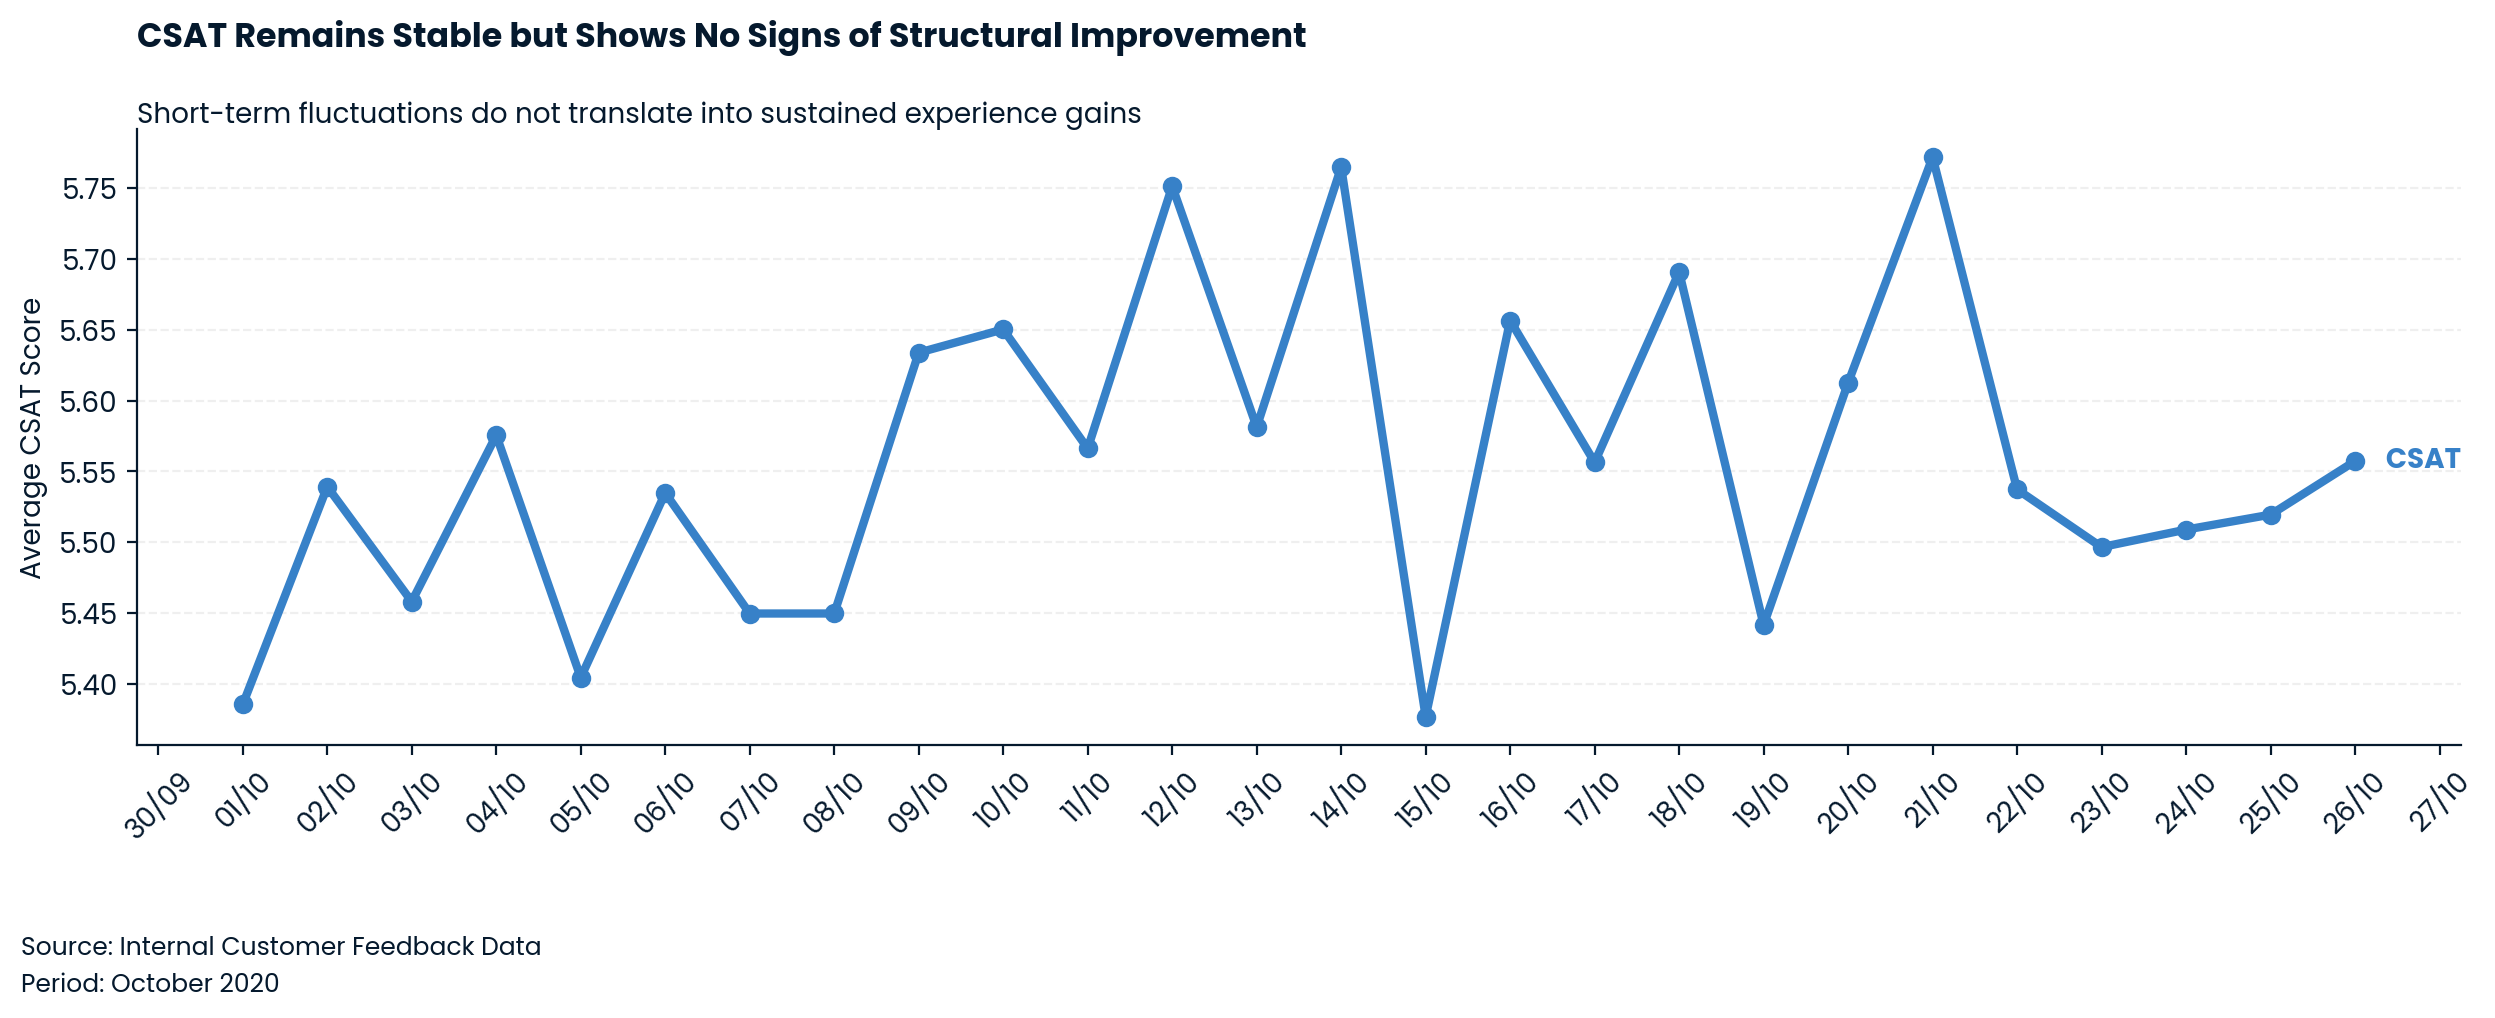

In [92]:
# =========================
# 1. Preparação
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df["call_timestamp"] = pd.to_datetime(df["call_timestamp"])
df["date"] = df["call_timestamp"].dt.floor("D")

# remover último dia (incompleto)
df_csat = df[df["date"] < df["date"].max()]

# =========================
# 2. CSAT Score Diário
# =========================

csat_daily = (
    df_csat.groupby("date")["csat_score"]
    .mean()
    .sort_index()
)

# garantir continuidade temporal
full_range = pd.date_range(
    start=csat_daily.index.min(),
    end=csat_daily.index.max(),
    freq="D"
)

csat_daily = csat_daily.reindex(full_range)
csat_daily.index.name = "date"

# =========================
# 3. Plot (padrão executivo)
# =========================

plt.figure(figsize=(14, 6))
ax = plt.gca()

line, = ax.plot(
    csat_daily.index,
    csat_daily.values,
    marker='o',
    color="#3781C8",
    linewidth=3,
    zorder=3
)

# label direto na linha (sem legenda)
x_margin = pd.Timedelta(days=0.3)
ax.text(
    csat_daily.index[-1] + x_margin,
    csat_daily.iloc[-1],
    " CSAT",
    color=line.get_color(),
    va='center',
    fontsize=10,
    fontweight='bold'
)

# =========================
# 4. Eixos e formatação
# =========================

ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
plt.xticks(rotation=45)

# remover bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# grid leve
plt.grid(axis='y', linestyle='--', alpha=0.2)

# =========================
# 5. Narrativa (INSIGHT)
# =========================

title = "CSAT Remains Stable but Shows No Signs of Structural Improvement"

subtitle = (
    "Short-term fluctuations do not translate into sustained experience gains"
)

ax.text(
    0.0, 1.12,
    title,
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=12,
    fontweight='bold'
)

ax.text(
    0.0, 1.0,
    subtitle,
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=10
)

# =========================
# 6. Metadados
# =========================

ax.text(
    x=-0.05, y=-0.34,
    s='Source: Internal Customer Feedback Data',
    fontsize=9,
    transform=ax.transAxes,
    ha='left'
)

ax.text(
    x=-0.05, y=-0.40,
    s=f'Period: {csat_daily.index.min().strftime("%B %Y")}',
    fontsize=9,
    transform=ax.transAxes,
    ha='left'
)

# =========================
# 7. Labels finais
# =========================

plt.xlabel("")
plt.ylabel("Average CSAT Score")

plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.show()

CSAT levels remain relatively stable throughout the month, fluctuating within a narrow range.

Although there are occasional peaks, these improvements are not sustained over time, indicating the absence of structural gains in customer satisfaction.

This suggests that while the operation maintains a consistent baseline experience, it fails to address the root causes necessary to significantly improve customer perception.

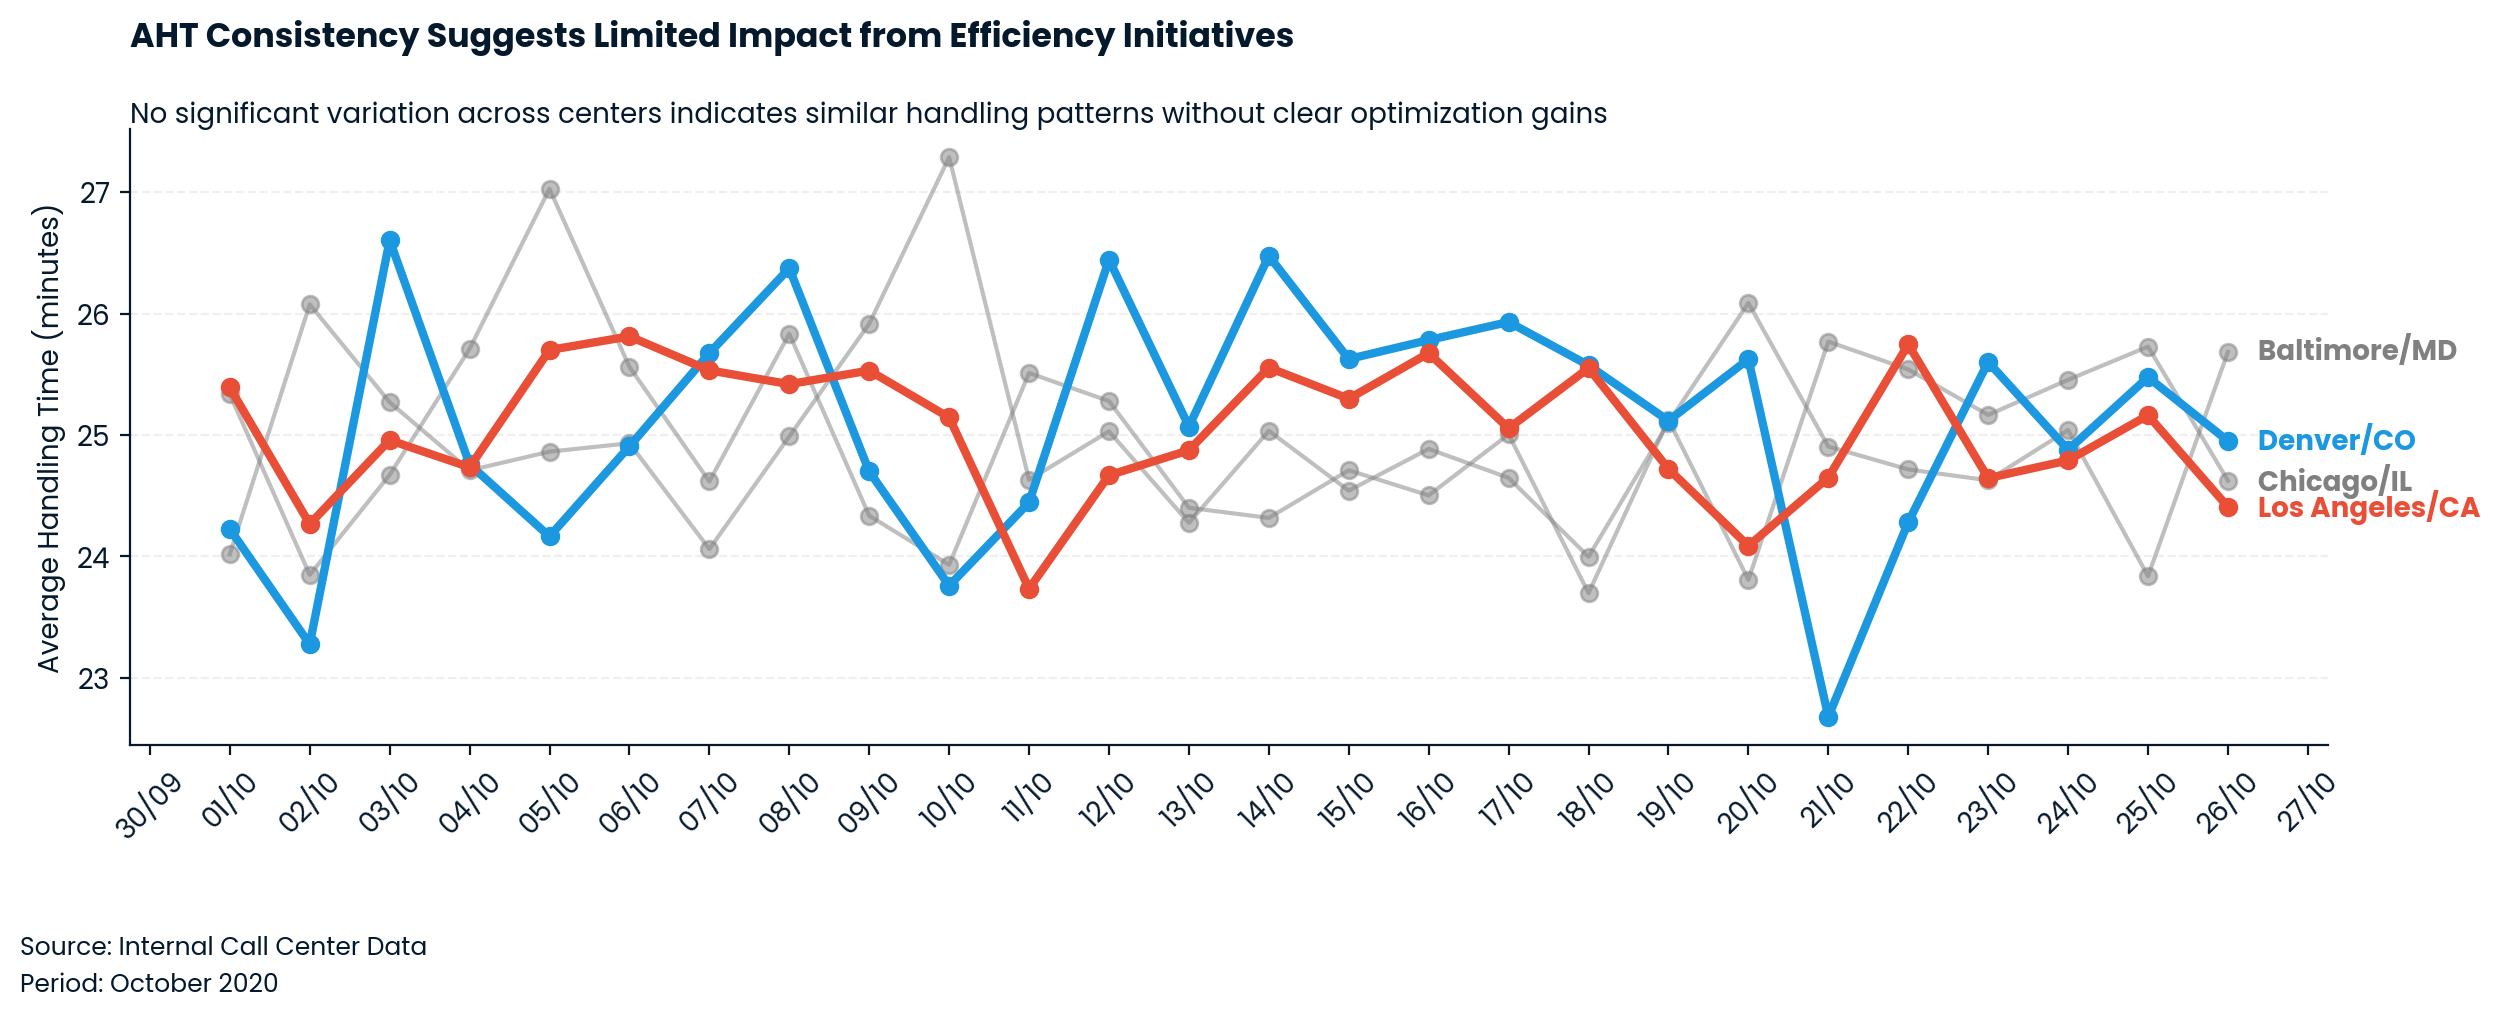

In [94]:
# =========================
# 1. Preparação
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df["call_timestamp"] = pd.to_datetime(df["call_timestamp"])
df["date"] = df["call_timestamp"].dt.floor("D")

# remover último dia (incompleto)
df_aht = df[df["date"] < df["date"].max()]

# =========================
# 2. Média de AHT Diário por Call Center
# =========================

aht_mean_daily_callcenter = (
    df_aht.groupby(["date", "call_center"])["aht"]
    .mean()
    .unstack("call_center")
    .sort_index()
)

# garantir continuidade temporal
full_range = pd.date_range(
    start=aht_mean_daily_callcenter.index.min(),
    end=aht_mean_daily_callcenter.index.max(),
    freq="D"
)

aht_mean_daily_callcenter = aht_mean_daily_callcenter.reindex(full_range)
aht_mean_daily_callcenter.index.name = "date"

# =========================
# 3. Plot (padrão executivo)
# =========================

plt.figure(figsize=(14, 6))
ax = plt.gca()

# destaque estratégico (mesmo padrão do gráfico anterior)
highlight_centers = {
    "Los Angeles/CA": "#E94F37",
    "Denver/CO": "#1B98E0"
}

for col in aht_mean_daily_callcenter.columns:
    if col in highlight_centers:
        line, = ax.plot(
            aht_mean_daily_callcenter.index,
            aht_mean_daily_callcenter[col],
            marker='o',
            linewidth=3,
            color=highlight_centers[col],
            zorder=3
        )
    else:
        line, = ax.plot(
            aht_mean_daily_callcenter.index,
            aht_mean_daily_callcenter[col],
            marker='o',
            linewidth=1.5,
            color='gray',
            alpha=0.5,
            zorder=2
        )

    # label direto na linha
    x_margin = pd.Timedelta(days=0.3)
    ax.text(
        aht_mean_daily_callcenter.index[-1] + x_margin,
        aht_mean_daily_callcenter[col].iloc[-1],
        f' {col}',
        color=line.get_color(),
        va='center',
        fontsize=10,
        fontweight='bold'
    )

# =========================
# 4. Eixos e formatação
# =========================

ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
plt.xticks(rotation=45)

# remover bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# grid leve
plt.grid(axis='y', linestyle='--', alpha=0.2)

# =========================
# 5. Narrativa
# =========================

title = "AHT Consistency Suggests Limited Impact from Efficiency Initiatives"

subtitle = (
    "No significant variation across centers indicates similar handling patterns without clear optimization gains"
)

ax.text(
    0.0, 1.12,
    title,
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=12,
    fontweight='bold'
)

ax.text(
    0.0, 1.0,
    subtitle,
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=10
)

# =========================
# 6. Metadados
# =========================

ax.text(
    x=-0.05, y=-0.34,
    s='Source: Internal Call Center Data',
    fontsize=9,
    transform=ax.transAxes,
    ha='left'
)

ax.text(
    x=-0.05, y=-0.40,
    s=f'Period: {aht_mean_daily_callcenter.index.min().strftime("%B %Y")}',
    fontsize=9,
    transform=ax.transAxes,
    ha='left'
)

# =========================
# 7. Labels finais
# =========================

plt.xlabel("")
plt.ylabel("Average Handling Time (minutes)")

plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.show()

Average Handle Time (AHT) remains relatively consistent across call centers and throughout the month.

There are no significant deviations that indicate efficiency gains or performance issues in specific locations.

While stability suggests operational control, it also indicates a lack of optimization, as no center demonstrates superior efficiency that could be leveraged as a benchmark.

This reinforces that improving SLA performance will depend more on workload distribution than on handling efficiency alone.

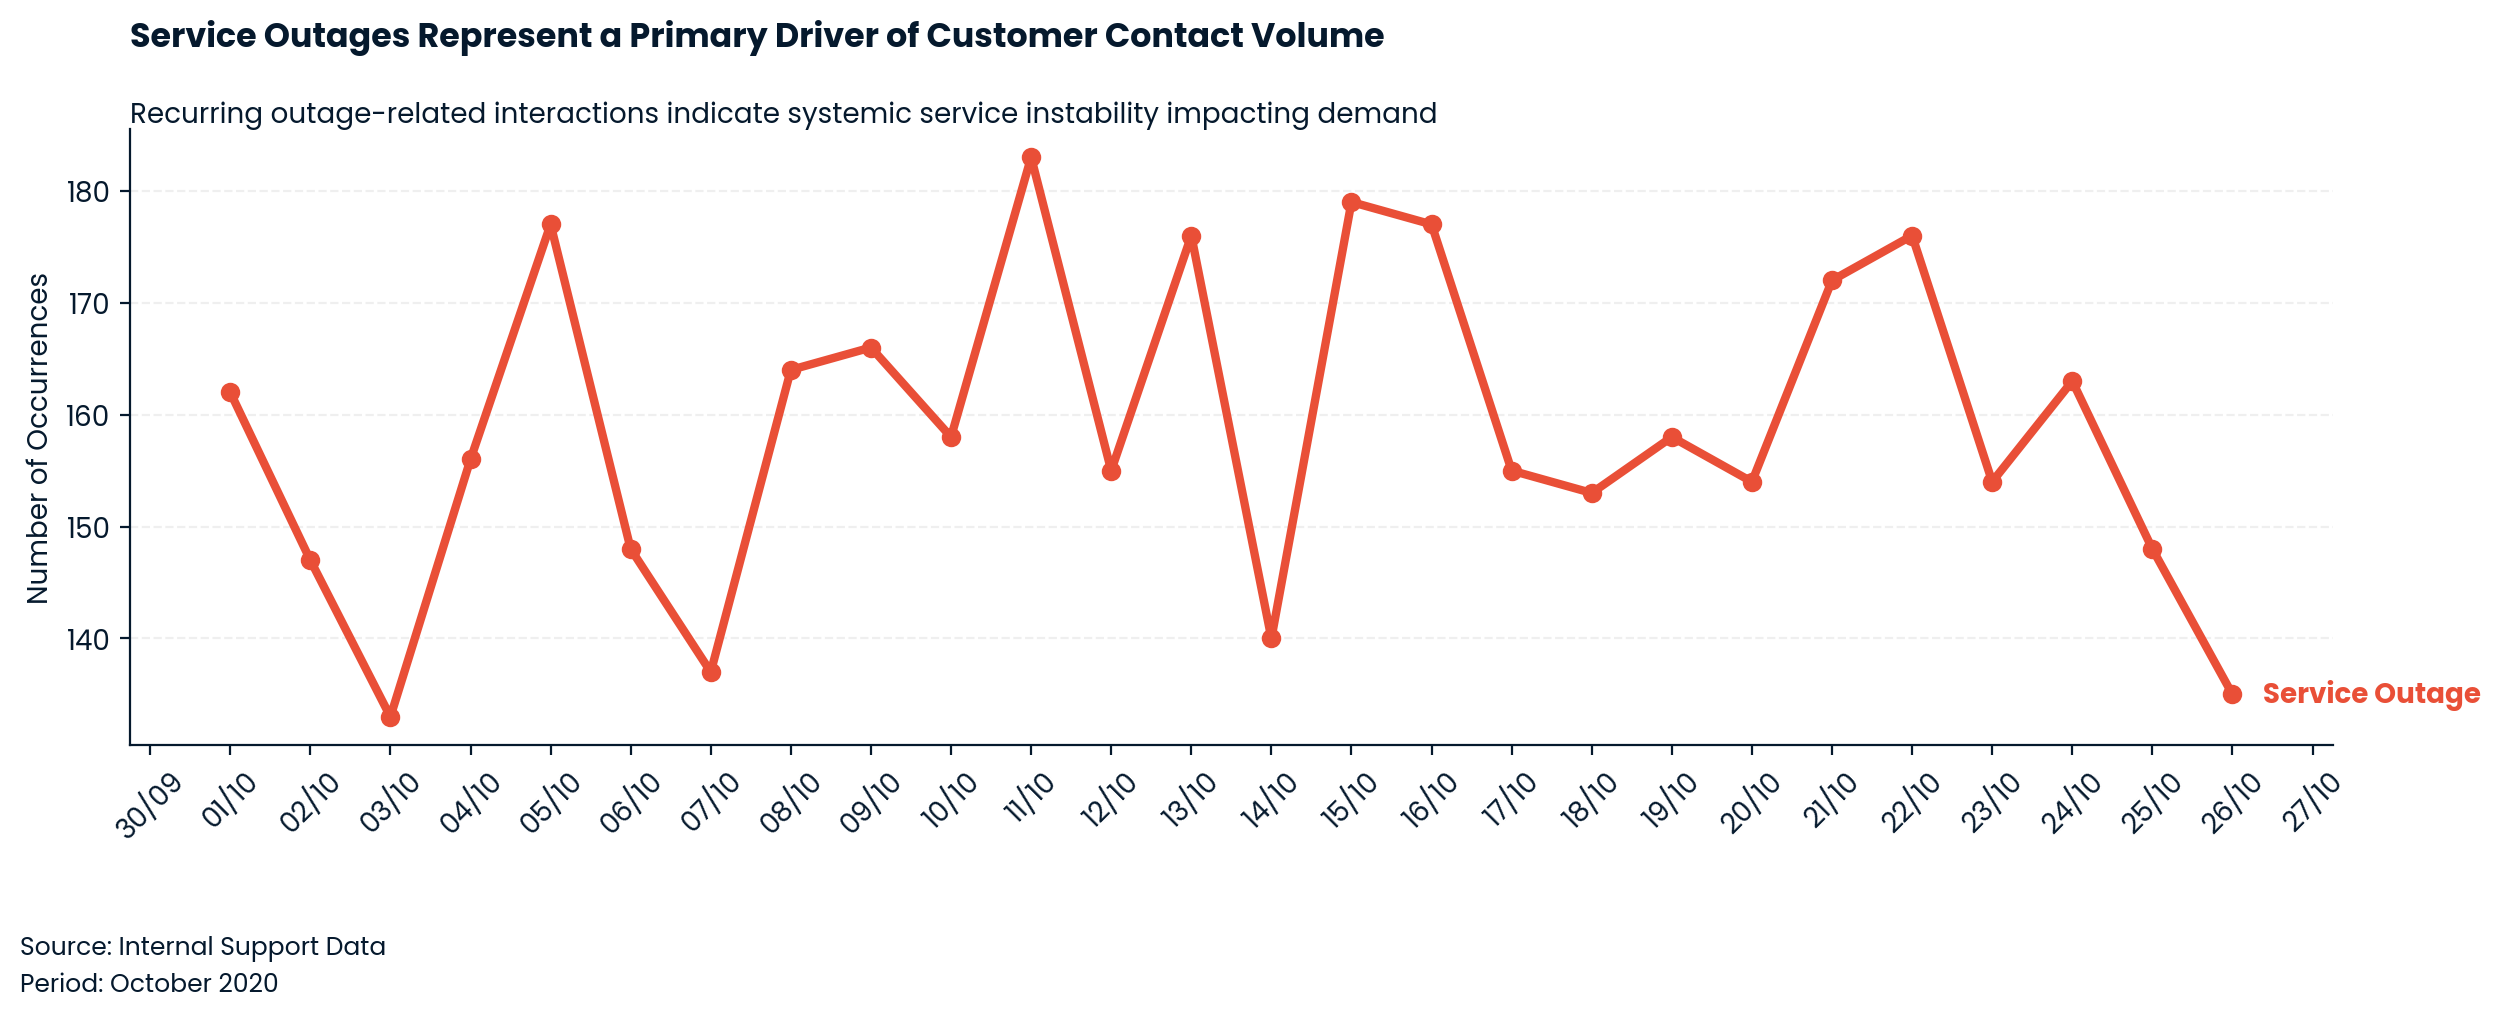

In [95]:
# =========================
# 1. Preparação
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# garantir datetime
df["call_timestamp"] = pd.to_datetime(df["call_timestamp"])
df["date"] = df["call_timestamp"].dt.floor("D")

# remover último dia (incompleto)
df_csat = df[df["date"] < df["date"].max()]

# =========================
# 2. Filtrar e agregar
# =========================

df_outage = df_csat[df_csat["reason"] == "Service Outage"]

outage_daily = (
    df_outage.groupby("date")["id"]
    .count()
    .sort_index()
)

# garantir continuidade temporal (IMPORTANTE)
full_range = pd.date_range(
    start=outage_daily.index.min(),
    end=outage_daily.index.max(),
    freq="D"
)

outage_daily = outage_daily.reindex(full_range, fill_value=0)
outage_daily.index.name = "date"

# =========================
# 3. Plot (padrão executivo)
# =========================

plt.figure(figsize=(14, 6))
ax = plt.gca()

line, = ax.plot(
    outage_daily.index,
    outage_daily.values,
    marker='o',
    color="#E94F37",
    linewidth=3,
    zorder=3
)

# label direto na linha (substitui legenda)
x_margin = pd.Timedelta(days=0.3)
ax.text(
    outage_daily.index[-1] + x_margin,
    outage_daily.iloc[-1],
    " Service Outage",
    color=line.get_color(),
    va='center',
    fontsize=10,
    fontweight='bold'
)

# =========================
# 4. Eixos e formatação
# =========================

ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
plt.xticks(rotation=45)

# remover bordas desnecessárias
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# grid leve
plt.grid(axis='y', linestyle='--', alpha=0.2)

# =========================
# 5. Narrativa (TÍTULO + SUBTÍTULO)
# =========================

title = "Service Outages Represent a Primary Driver of Customer Contact Volume"

subtitle = (
    "Recurring outage-related interactions indicate systemic service instability impacting demand"
)

ax.text(
    0.0, 1.12,
    title,
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=12,
    fontweight='bold'
)

ax.text(
    0.0, 1.0,
    subtitle,
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=10
)

# =========================
# 6. Metadados
# =========================

ax.text(
    x=-0.05, y=-0.34,
    s='Source: Internal Support Data',
    fontsize=9,
    transform=ax.transAxes,
    ha='left'
)

ax.text(
    x=-0.05, y=-0.40,
    s=f'Period: {outage_daily.index.min().strftime("%B %Y")}',
    fontsize=9,
    transform=ax.transAxes,
    ha='left'
)

# =========================
# 7. Labels finais
# =========================

plt.xlabel("")
plt.ylabel("Number of Occurrences")

plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.show()

# 3.0 Recomendations 

Based on the analysis of October 2020, two key actions are recommended to address SLA underperformance and improve operational efficiency:

1. Optimize Workload Distribution Across Call Centers
- Redistribute incoming interactions dynamically based on real-time capacity and demand.
- Reduce overload in high-volume centers such as Los Angeles and Baltimore by routing calls to underutilized centers like Denver.

This will balance operational pressure, improve resource utilization, and directly increase SLA compliance.

2. Strengthen Incident Visibility and SRE Collaboration
- Customer sentiment and interaction reasons indicate recurring service issues, particularly related to outages.
- Implement a structured reporting mechanism to flag peaks in specific contact reasons (e.g., service outages) and proactively notify the SRE team.

This enables faster root cause investigation and resolution, reducing repeated contacts and improving both SLA and customer experience.

# Credits

- [LinkedIn — jvroot](https://www.linkedin.com/in/jvroot/)
- [GitHub — JV-root](https://github.com/JV-root)

Thank you for visiting this notebook! For more projects and professional updates, feel free to connect via LinkedIn or explore my GitHub repositories.